# Text classification with LSTM and CNN, and an empirical look at gradient clipping

This notebook builds two neural text classifiers and compares them on the same dataset split and metrics.

1. Train an LSTM based classifier for sentiment classification.
2. Add gradient clipping to stabilize training and verify its effect.
3. Train a CNN based text classifier and compare CNN vs LSTM using the same split, same metrics, and the same evaluation protocol.


In [1]:
# If you run this in a fresh environment, install dependencies.

# !pip install torch datasets tqdm matplotlib scikit-learn pandas
# !pip install -q --upgrade datasets


## Imports and reproducibility

In [2]:
import re
import random
from collections import Counter
from dataclasses import dataclass
from pandas import DataFrame


import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report


def set_seed(seed: int = 13) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(13)

if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("Using CPU")
    device = torch.device("cpu")
device

/Users/atodrv/Documents/Uni/TA/NLP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using CPU


device(type='cpu')

## Load the dataset

We use Yelp Polarity, which contains many reviews. When initially experimenting, it is often helpful to have quick runs and experiment on subsamples first to ensure everything works as intended. Then, later in the pipeline you can increase to the full dataset if needed.

We create three splits:

- train for gradient updates
- validation for early stopping and model selection
- test for a final report after all choices are fixed

The validation split is created from the original training split.


In [3]:
raw = load_dataset("yelp_polarity")

raw["train"], raw["test"]

(Dataset({
     features: ['text', 'label'],
     num_rows: 560000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 38000
 }))

It is often useful to first look at an example.

In [4]:
for i in range(5):
    print(f"Example {i}:\n{raw['train'][i]}\n")

Example 0:
{'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.", 'label': 0}

Example 1:
{'text': "Been going to Dr. Goldberg for over 10 years. I think I was one of his 1st patients when he started at MHMG. He's been great over the years and is really all about the big picture. It is because of him, not my now former gyn Dr. Markoff, that I found out I have fibroids. He explores all options wit

In [5]:
# Subsample for speed. You can increase these if you want stronger results.
N_TRAIN = 5000
N_VAL = 1000
N_TEST = 1000

train_full = raw["train"].shuffle(seed=13)  # We only shuffle the training set.
test_full = raw["test"].shuffle(seed=13)

train_ds_hf = train_full.select(range(N_TRAIN + N_VAL))
test_ds_hf = test_full.select(range(N_TEST))

val_ds_hf = train_ds_hf.select(range(N_TRAIN, N_TRAIN + N_VAL))
train_ds_hf = train_ds_hf.select(range(N_TRAIN))

print(
    f"Dataset lengths: train={len(train_ds_hf)}, val={len(val_ds_hf)}, test={len(test_ds_hf)}"
)

Dataset lengths: train=5000, val=1000, test=1000


## Tokenization and vocabulary

To keep the pipeline transparent, we use a simple word tokenizer based on regular expressions. This is not state of the art tokenization, but it makes it easy to reason about what the model sees. In practice, one oftens uses more advanced tokenizers.

The vocabulary is built from the training data only. This matters because using validation or test text to build the vocabulary leaks information into training.

We use special tokens:
- <pad> for padding inside batches
- <unk> for words that are not in the vocabulary


In [ ]:
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")


def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())


PAD = "<pad>"
UNK = "<unk>"


def build_vocab(texts, min_freq: int = 2, max_size: int = 30000) -> dict:
    """
    Build a vocabulary mapping from tokens to integer indices.
    The vocabulary will include only tokens that appear at least `min_freq` times,
    and will be limited to `max_size` tokens (including PAD and UNK).
    """
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    # Reserve 0 for PAD and 1 for UNK.
    vocab = {PAD: 0, UNK: 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            break
        if len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab


vocab = build_vocab(train_ds_hf["text"], min_freq=2, max_size=30000)
vocab_size = len(vocab)
PAD_IDX = vocab[PAD]
vocab_size, list(vocab.items())[:10]


(12978,
 [('<pad>', 0),
  ('<unk>', 1),
  ('the', 2),
  ('and', 3),
  ('i', 4),
  ('to', 5),
  ('a', 6),
  ('was', 7),
  ('of', 8),
  ('it', 9)])

In [7]:
def numericalize(tokens: list, vocab: dict) -> list:
    """
    Convert a list of tokens into a list of integer indices using the provided vocabulary.
    Tokens not found in the vocabulary will be mapped to the index of UNK.
    """
    return [vocab.get(tok, vocab[UNK]) for tok in tokens]


# Sanity check
sample = train_ds_hf[0]["text"]
tokenize(sample)[:20], numericalize(tokenize(sample)[:20], vocab)[:20]

(['i',
  'have',
  'found',
  'my',
  'last',
  'meal',
  'nmy',
  'wife',
  'and',
  'i',
  'first',
  'came',
  'to',
  'love',
  'bouchon',
  'in',
  '2009',
  'while',
  'staying',
  'at'],
 [4,
  24,
  283,
  15,
  180,
  212,
  484,
  412,
  3,
  4,
  107,
  101,
  5,
  137,
  3498,
  11,
  4557,
  164,
  912,
  26])

## Dataset and collate function

We first define some custom classes and Dataset classes that are required for the proper running of the classification pipeline.


In [8]:
@dataclass
class Batch:
    x: torch.Tensor  # (B, T) token ids
    lengths: torch.Tensor  # (B,) true lengths
    y: torch.Tensor  # (B,) labels


class TextDataset(Dataset):
    def __init__(self, hf_ds: dict, vocab: dict, max_len: int = 200) -> None:
        self.ds = hf_ds
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.ds)

    def __getitem__(self, idx: int) -> tuple:
        """Given an index, return the token ids and label for the corresponding sample."""
        item = self.ds[idx]
        tokens = tokenize(item["text"])

        # Convert to ids and truncate
        if len(tokens) == 0:
            ids = [self.vocab[UNK]]
        else:
            ids = numericalize(tokens, self.vocab)[: self.max_len]
            if len(ids) == 0:
                ids = [self.vocab[UNK]]

        label = int(item["label"])  # 0 negative, 1 positive
        return ids, label


def collate(batch: list) -> Batch:
    """Collate function to convert a list of samples into a batch."""
    # batch: list of (ids_list, label)
    lengths = torch.tensor([len(x) for x, _ in batch], dtype=torch.long)
    max_len = int(lengths.max().item()) if len(batch) > 0 else 0
    x = torch.full((len(batch), max_len), vocab[PAD], dtype=torch.long)
    y = torch.tensor([y for _, y in batch], dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        x[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)
    return Batch(x=x, lengths=lengths, y=y)

We represent each example as a sequence of token ids. However, we need to truncate very long reviews and pad the rest to form batches (so that they are of uniform size) as RNNs expect sequences in a batch to have the same length.

The idea is to pad shorter examples up to the longest example in the batch. Very long reviews can dominate memory and runtime, so we also cap the maximum length and truncate beyond it.

We can plot the distribution of lengths in the training dataset to get an understanding of what is a reasonable max length.

We also keep the true sequence length, which is useful for masking and for selecting the correct hidden state when sequences have different lengths.

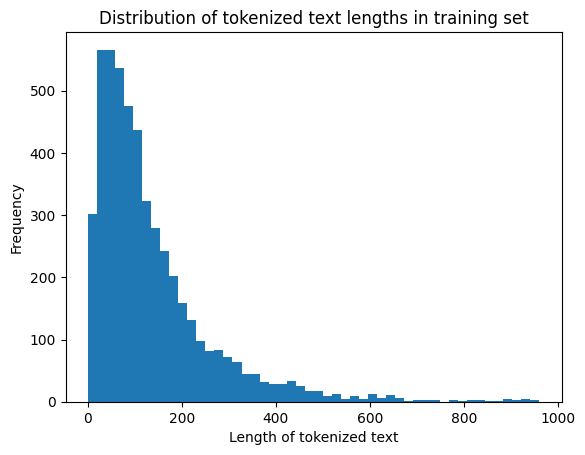

In [9]:
# Plot distribution of lengths in the training set
lengths = [len(tokenize(text)) for text in train_ds_hf["text"]]
plt.hist(lengths, bins=50)
plt.title("Distribution of tokenized text lengths in training set")
plt.xlabel("Length of tokenized text")
plt.ylabel("Frequency")
plt.show()

We choose the maximum length after inspecting the distribution above. Unfortunately, there is always a tradeoff:
 - larger MAX_LEN keeps more context but increases compute and padding waste
 - smaller MAX_LEN is faster but may drop important information for long reviews

For this tutorial, we will set MAX_LEN to 200, but of course, you can change it and compare the results. Note that training and the embedding size below will take significantly more time. A common practical choice is to set MAX_LEN around a high percentile, for example p90 or p95.

In terms of batch size, people often choose values that are powers of 2 (2, 4, 16, etc.). Smaller batch size generally leads to noisier gradients, but higher batch size requires more memory (RAM/VRAM on a GPU). Again, there is always a tradeoff and one chooses based on their goals and capabilities.

In [10]:
MAX_LEN = 200
BATCH_SIZE = 64

print(f"Using MAX_LEN={MAX_LEN} and BATCH_SIZE={BATCH_SIZE}")

train_ds = TextDataset(train_ds_hf, vocab, max_len=MAX_LEN)
val_ds = TextDataset(val_ds_hf, vocab, max_len=MAX_LEN)
test_ds = TextDataset(test_ds_hf, vocab, max_len=MAX_LEN)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate
)

batch0 = next(iter(train_loader))
print("One batch shapes")
print(
    "x:",
    tuple(batch0.x.shape),
    "lengths:",
    tuple(batch0.lengths.shape),
    "y:",
    tuple(batch0.y.shape),
)
print("Example lengths:", batch0.lengths[:10].tolist())

Using MAX_LEN=200 and BATCH_SIZE=64
One batch shapes
x: (64, 200) lengths: (64,) y: (64,)
Example lengths: [171, 200, 200, 185, 200, 55, 200, 58, 124, 200]


## Models

We implement two architectures.

LSTM classifier. We encode a padded token sequence with an LSTM and use the last layer final hidden state as a sentence representation.

CNN text classifier. We apply multiple 1D convolution filters over the token embeddings, then max pool over time for each filter, concatenate, and classify.


In [11]:

class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        hidden_dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0.3,
        pad_idx: int = 0,
        num_classes: int = 2,
        bidirectional: bool = False,
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        rep_dim = hidden_dim * (2 if bidirectional else 1)
        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(rep_dim, num_classes)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        emb = self.emb_dropout(self.embedding(x))  # (B, T, E)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)  # h_n: (num_layers * dirs, B, H)
        h_last = h_n[-1]  # last layer, last direction
        rep = self.rep_dropout(h_last)
        return self.fc(rep)


class CNNTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        num_filters: int = 64,
        kernel_sizes: tuple = (3, 4, 5),
        dropout: float = 0.3,
        pad_idx: int = 0,
        num_classes: int = 2,
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)
        self.convs = nn.ModuleList(
            [nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
             for k in kernel_sizes]
        )
        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        # x: (B, T)
        emb = self.emb_dropout(self.embedding(x))  # (B, T, E)
        emb_t = emb.transpose(1, 2)  # (B, E, T) for Conv1d
        pooled = []
        for conv in self.convs:
            z = torch.relu(conv(emb_t))  # (B, F, T-k+1)
            p = torch.max(z, dim=2).values  # (B, F)
            pooled.append(p)
        rep = torch.cat(pooled, dim=1)  # (B, F * |K|)
        rep = self.rep_dropout(rep)
        return self.fc(rep)


# Quick shape sanity check
set_seed(13)
x_demo = torch.randint(low=0, high=vocab_size, size=(4, 20))
len_demo = torch.tensor([20, 18, 12, 7])
print("LSTM logits shape:", LSTMClassifier(vocab_size=vocab_size)(x_demo, len_demo).shape)
print("CNN logits shape: ", CNNTextClassifier(vocab_size=vocab_size)(x_demo, len_demo).shape)


LSTM logits shape: torch.Size([4, 2])
CNN logits shape:  torch.Size([4, 2])


## Training utilities with gradient clipping

We use cross entropy loss and Adam.

After backpropagation we clip the gradient norm to a fixed threshold. We also log the pre clipping gradient norm so that we can empirically verify whether clipping is active and whether it changes learning dynamics.


In [12]:

def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    all_y = []
    all_pred = []
    total_loss = 0.0
    n = 0
    loss_fn = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)

            logits = model(x, lengths)
            loss = loss_fn(logits, y)

            pred = logits.argmax(dim=1)
            all_y.append(y.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            total_loss += loss.item() * y.size(0)
            n += y.size(0)

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    return {
        "loss": total_loss / max(1, n),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    lr: float = 1e-3,
    max_epochs: int = 20,
    weight_decay: float = 0.0,
    clip_grad_norm: float | None = None,
    patience: int | None = 3,
) -> list:
    """
    Train the model, optionally with early stopping on validation loss.

    If clip_grad_norm is not None, gradients are clipped by global norm after backward.
    We log the pre clipping total gradient norm each epoch.
    """
    loss_fn = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    hist = []
    for epoch in range(1, max_epochs + 1):
        model.train()
        t0 = time.perf_counter()

        total_loss = 0.0
        n = 0
        correct = 0

        grad_norms = []

        for batch in train_loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)

            optim.zero_grad(set_to_none=True)
            logits = model(x, lengths)
            loss = loss_fn(logits, y)
            loss.backward()

            # Measure global grad norm before clipping.
            total_norm_sq = 0.0
            for p in model.parameters():
                if p.grad is None:
                    continue
                param_norm = p.grad.data.norm(2).item()
                total_norm_sq += param_norm * param_norm
            total_norm = float(total_norm_sq ** 0.5)
            grad_norms.append(total_norm)

            if clip_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

            optim.step()

            total_loss += loss.item() * y.size(0)
            n += y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()

        train_loss = total_loss / max(1, n)
        train_acc = correct / max(1, n)
        val = evaluate(model, val_loader)
        dt = time.perf_counter() - t0

        record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val["loss"],
            "val_acc": val["acc"],
            "val_f1": val["f1"],
            "time_s": dt,
            "grad_norm_mean": float(np.mean(grad_norms)) if len(grad_norms) else float("nan"),
            "grad_norm_p95": float(np.percentile(grad_norms, 95)) if len(grad_norms) else float("nan"),
            "grad_norm_max": float(np.max(grad_norms)) if len(grad_norms) else float("nan"),
        }
        hist.append(record)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val['loss']:.4f} acc {val['acc']:.4f} f1 {val['f1']:.4f} | "
            f"grad norm mean {record['grad_norm_mean']:.2f} max {record['grad_norm_max']:.2f} | "
            f"time {dt:.1f}s"
        )

        if patience is not None:
            if val["loss"] < best_val - 1e-6:
                best_val = val["loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print("Early stopping triggered, restoring best parameters.")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break

    if patience is not None and best_state is not None:
        model.load_state_dict(best_state)

    return hist


## Empirical experiment: when gradient clipping matters

We deliberately choose a setting that often produces unstable optimization for an LSTM. We increase the learning rate so that gradients can blow up.

We run the same model twice.
1. No clipping.
2. Clipping with max norm 2.0.

We compare the observed gradient norms and the training curves. If clipping is doing nothing, the logged gradient norms will stay small and the two runs will look similar.


epoch 01 | train loss 0.7054 acc 0.5272 | val loss 0.6400 acc 0.6480 f1 0.6475 | grad norm mean 0.23 max 2.25 | time 8.3s
epoch 02 | train loss 0.5744 acc 0.7142 | val loss 0.5054 acc 0.7780 f1 0.7777 | grad norm mean 0.40 max 2.25 | time 7.8s
epoch 03 | train loss 0.4678 acc 0.7908 | val loss 0.4957 acc 0.7790 f1 0.7789 | grad norm mean 0.53 max 1.28 | time 7.9s
epoch 04 | train loss 0.5188 acc 0.7630 | val loss 0.6205 acc 0.6920 f1 0.6833 | grad norm mean 0.94 max 14.55 | time 7.8s
epoch 05 | train loss 0.4080 acc 0.8228 | val loss 0.6070 acc 0.7690 f1 0.7606 | grad norm mean 1.09 max 17.27 | time 7.8s
epoch 06 | train loss 0.4297 acc 0.8134 | val loss 0.5929 acc 0.7390 f1 0.7319 | grad norm mean 1.19 max 6.10 | time 7.8s
epoch 07 | train loss 0.4903 acc 0.7716 | val loss 0.6358 acc 0.6820 f1 0.6755 | grad norm mean 1.33 max 4.36 | time 7.7s
epoch 08 | train loss 0.5051 acc 0.7668 | val loss 0.7510 acc 0.6470 f1 0.6385 | grad norm mean 2.83 max 24.26 | time 7.8s
epoch 01 | train loss

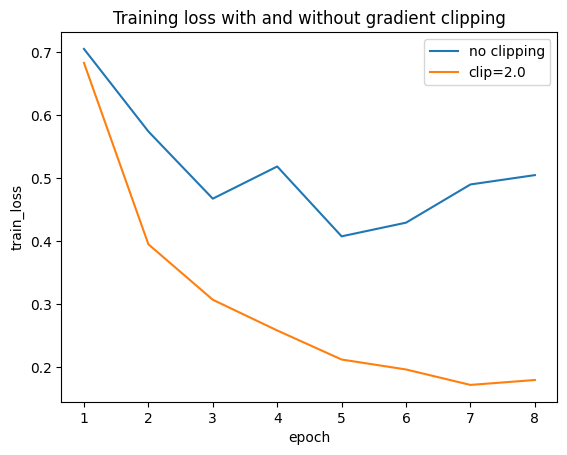

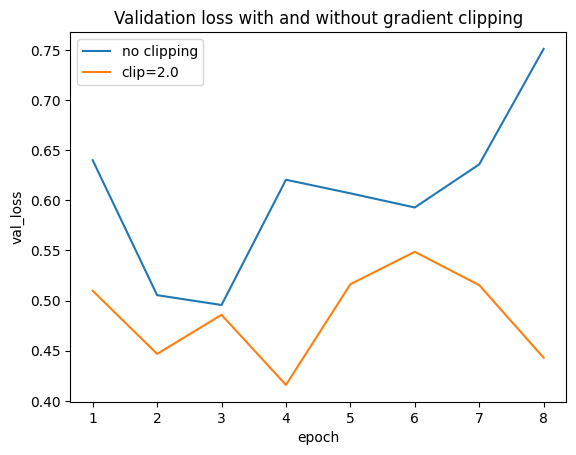

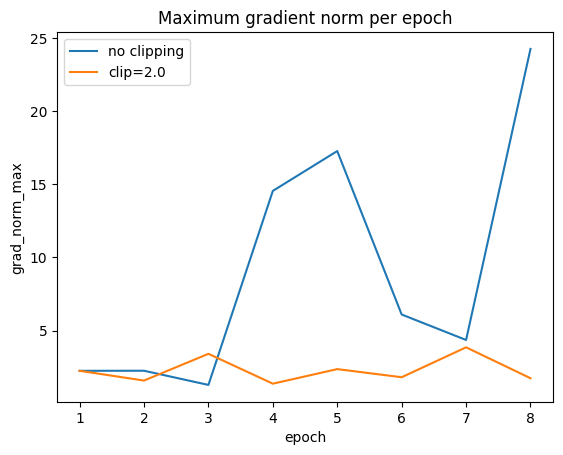

Final diagnostic validation metrics
No clipping: 0.647 0.6385385488909892
Clipping:    0.816 0.8155388471177945


In [13]:

set_seed(7)

train_ds_small = TextDataset(train_ds_hf, vocab, max_len=MAX_LEN)
val_ds_small = TextDataset(val_ds_hf, vocab, max_len=MAX_LEN)

train_loader_small = DataLoader(train_ds_small, batch_size=64, shuffle=True, collate_fn=collate)
val_loader_small = DataLoader(
    val_ds_small, batch_size=256, shuffle=False, collate_fn=collate
)

def run_clip_diagnostic(clip: float | None):
    set_seed(7)
    m = LSTMClassifier(
        vocab_size=vocab_size,
        embed_dim=64,
        hidden_dim=64,
        num_layers=2,
        dropout=0.1,
        pad_idx=PAD_IDX,
    ).to(device)

    hist = fit(
        m,
        train_loader_small,
        val_loader_small,
        lr=5e-2,
        max_epochs=8,
        patience=None,
        clip_grad_norm=clip,
    )
    return m, hist

model_no_clip, hist_no_clip = run_clip_diagnostic(None)
model_clip, hist_clip = run_clip_diagnostic(2.0)

def plot_hist(h1, h2, key: str, title: str):
    e1 = [r["epoch"] for r in h1]
    e2 = [r["epoch"] for r in h2]
    y1 = [r[key] for r in h1]
    y2 = [r[key] for r in h2]

    plt.figure()
    plt.plot(e1, y1, label="no clipping")
    plt.plot(e2, y2, label="clip=2.0")
    plt.xlabel("epoch")
    plt.ylabel(key)
    plt.title(title)
    plt.legend()
    plt.show()

plot_hist(hist_no_clip, hist_clip, "train_loss", "Training loss with and without gradient clipping")
plot_hist(hist_no_clip, hist_clip, "val_loss", "Validation loss with and without gradient clipping")
plot_hist(hist_no_clip, hist_clip, "grad_norm_max", "Maximum gradient norm per epoch")

print("Final diagnostic validation metrics")
print("No clipping:", evaluate(model_no_clip, val_loader_small)["acc"], evaluate(model_no_clip, val_loader_small)["f1"])
print("Clipping:   ", evaluate(model_clip, val_loader_small)["acc"], evaluate(model_clip, val_loader_small)["f1"])


## CNN vs LSTM comparison on the main split

We now train both models with the same train and validation splits, the same maximum sequence length, the same tokenization and vocabulary, and the same evaluation metrics.

We also measure wall clock training time.


In [14]:

set_seed(13)

MAX_EPOCHS = 12
PATIENCE = 3
LR = 1e-3
CLIP = 1.0

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_and_time(name: str, model: nn.Module):
    t0 = time.perf_counter()
    hist = fit(
        model,
        train_loader,
        val_loader,
        lr=LR,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        clip_grad_norm=CLIP,
    )
    total_time = time.perf_counter() - t0
    val = evaluate(model, val_loader)
    test = evaluate(model, test_loader)
    return {
        "name": name,
        "hist": hist,
        "val": val,
        "test": test,
        "time_s_total": total_time,
    }

lstm = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3,
    pad_idx=PAD_IDX,
).to(device)

cnn = CNNTextClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    num_filters=64,
    kernel_sizes=(3,4,5),
    dropout=0.3,
    pad_idx=PAD_IDX,
).to(device)


print("Number of trainable parameters:")
print("LSTM:", count_parameters(lstm))
print("CNN: ", count_parameters(cnn))

print("Training LSTM...")
res_lstm = train_and_time("LSTM", lstm)

print("Training CNN...")
res_cnn = train_and_time("CNN", cnn)

rows = []
for res in [res_lstm, res_cnn]:
    rows.append([
        res["name"],
        res["val"]["acc"],
        res["val"]["f1"],
        res["test"]["acc"],
        res["test"]["f1"],
        res["time_s_total"],
    ])

df_compare = DataFrame(
    rows,
    columns=["model", "val_acc", "val_macro_f1", "test_acc", "test_macro_f1", "train_time_s"],
).sort_values(by=["val_macro_f1", "val_acc"], ascending=False).reset_index(drop=True)

display(df_compare)


Number of trainable parameters:
LSTM: 897282
CNN:  880322
Training LSTM...
epoch 01 | train loss 0.6804 acc 0.5520 | val loss 0.5910 acc 0.7010 f1 0.7005 | grad norm mean 0.22 max 1.15 | time 7.8s
epoch 02 | train loss 0.6129 acc 0.6794 | val loss 0.5572 acc 0.7200 f1 0.7176 | grad norm mean 1.59 max 18.49 | time 7.8s
epoch 03 | train loss 0.5483 acc 0.7288 | val loss 0.5071 acc 0.7590 f1 0.7564 | grad norm mean 1.36 max 5.11 | time 7.8s
epoch 04 | train loss 0.4849 acc 0.7784 | val loss 0.4709 acc 0.7790 f1 0.7789 | grad norm mean 1.43 max 9.79 | time 7.8s
epoch 05 | train loss 0.4329 acc 0.8092 | val loss 0.4805 acc 0.7890 f1 0.7885 | grad norm mean 2.34 max 26.12 | time 7.8s
epoch 06 | train loss 0.3930 acc 0.8272 | val loss 0.4100 acc 0.8260 f1 0.8244 | grad norm mean 1.95 max 10.33 | time 7.8s
epoch 07 | train loss 0.3600 acc 0.8438 | val loss 0.4053 acc 0.8260 f1 0.8260 | grad norm mean 1.88 max 6.11 | time 7.8s
epoch 08 | train loss 0.3241 acc 0.8668 | val loss 0.4095 acc 0.8230

,model,val_acc,val_macro_f1,test_acc,test_macro_f1,train_time_s
0,CNN,0.861,0.860993,0.862,0.861707,123.835316
1,LSTM,0.844,0.843984,0.852,0.851713,93.775420


### Learning curves

For a fair comparison, we plot the validation macro F1 and the validation loss over epochs for both models.

As an extra exercise, try rerunning the training setup with gradient clipping for both models and compare them again.


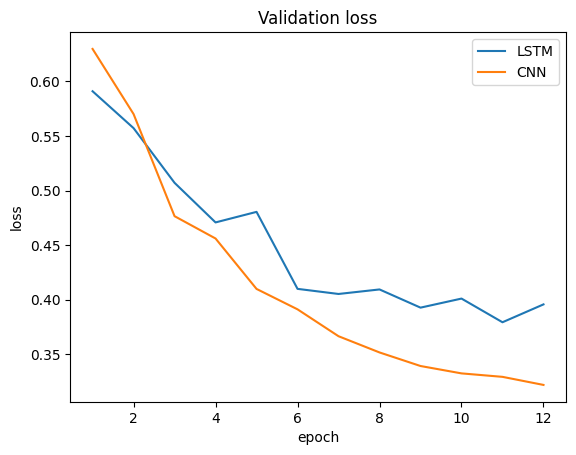

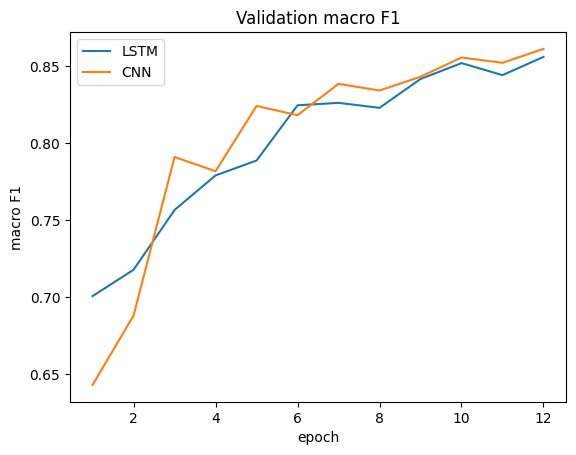

In [15]:

def plot_learning_curves(results, key: str, title: str, ylabel: str):
    plt.figure()
    for res in results:
        hist = res["hist"]
        epochs = [h["epoch"] for h in hist]
        vals = [h[key] for h in hist]
        plt.plot(epochs, vals, label=res["name"])
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

plot_learning_curves([res_lstm, res_cnn], "val_loss", "Validation loss", "loss")
plot_learning_curves([res_lstm, res_cnn], "val_f1", "Validation macro F1", "macro F1")


## Error analysis and failure modes

We inspect a small set of misclassified test examples for each model. This helps connect architecture choices to error patterns.

We show 5 to 10 errors per model with the true label, predicted label, and a truncated text snippet.


In [16]:

LABELS = {0: "negative", 1: "positive"}

def get_misclassified_examples(model: nn.Module, raw_split, max_items: int = 8):
    model.eval()
    errs = []
    for ex in raw_split:
        tokens = tokenize(ex["text"])
        ids = numericalize(tokens, vocab)[:MAX_LEN]
        x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
        lengths = torch.tensor([len(ids)], dtype=torch.long).to(device)
        y = int(ex["label"])
        with torch.no_grad():
            logits = model(x, lengths)
            pred = int(logits.argmax(dim=1).item())
        if pred != y:
            snippet = ex["text"].replace("\n", " ")
            snippet = snippet[:250] + ("..." if len(snippet) > 250 else "")
            errs.append((y, pred, snippet))
        if len(errs) >= max_items:
            break
    return errs

errs_lstm = get_misclassified_examples(lstm, raw["test"], max_items=10)
errs_cnn = get_misclassified_examples(cnn, raw["test"], max_items=10)

def show_errors(name: str, errs):
    print(name)
    for i,(y,p,snip) in enumerate(errs):
        print()
        print(f"error {i+1}")
        print("true:", LABELS[y], "pred:", LABELS[p])
        print("text:", snip)

show_errors("LSTM errors", errs_lstm[:8])
print("\n" + "="*80 + "\n")
show_errors("CNN errors", errs_cnn[:8])


LSTM errors

error 1
true: positive pred: negative
text: Contrary to other reviews, I have zero complaints about the service or the prices. I have been getting tire service here for the past 5 years now, and compared to my experience with places like Pep Boys, these guys are experienced and know what they'...

error 2
true: positive pred: negative
text: Even when we didn't have a car Filene's Basement was worth the bus trip to the Waterfront. I always find something (usually I find 3-4 things and spend about $60) and better still, I am always still wearing the clothes and shoes 3 months later. \n\nI...

error 3
true: negative pred: positive
text: When I think BBB... I think the days of simply bringing your bike in for a quick and relatively inexpensive tune-up and a few fixes are long gone.    \n\nThis review is more for the repair end of BBB. In their defense BBB does appear to carry some am...

error 4
true: positive pred: negative
text: This shelter is fantastic and has generally ve